Group 18 - Final Project

Air Quality Index Prediction Based on Historical Data and Wildfire Activity

Team Members:
1. Kara Fitzgerald - 30301723
2. Shehrukh Wasif - 30301927
3. Tami Adeleke - 30302315
4. Muhammad Anas Nawaz - 30262412

**Project Objective**:
Build a localized PM2.5 Forecasting model for Northwest Calgary using XGBoost (tabular regression) and LSTM (sequence learning) based on AQI, weather, and wildfire datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!ls

 aqi_pipeline_colab.ipynb	     ENGG680_2025_Fall
'Assignment2_Upload (jgh).ipynb'     ENGG680_Project
'Colab Notebooks'		    'Personal files'
'Copy of Assignment2_Upload.ipynb'  'Untitled document.gdoc'
'Data Set'


In [ ]:
%cd ENGG680_Project/

/content/drive/MyDrive/ENGG680_Project


In [ ]:
!ls

air_quality_data.csv  combined_weather_data.csv  wildfire_data.csv


In [ ]:

import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from IPython.display import display, HTML
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler


print("Python Libaries Imported")


Python Libaries Imported


**Reading and Cleaning Data files
(AQI, Weather and Wildfire)**
---

*Focus Area - Northwest Calgary*


In [46]:
#This uploads and reads the hisotrical air quality and
#weather data for Northwest Calgary
aqi = pd.read_csv("air_quality_data.csv")
weather = pd.read_csv("combined_weather_data.csv")
wildfire = pd.read_csv("wildfire_data.csv")

print("Files Upload Complete\n")

print ("Loaded AQI Shape:", aqi.shape)
display(aqi.head())

print ("\nLoaded Weather Shape:", weather.shape)
display(weather.head())

print ("\n Loaded Wildfire Shape:", wildfire.shape)
display(wildfire.head())

#The air_quality_csv contains the daily PM2.5 values ranging from 2008 to 2018
#The ccombined_weather data contains weather data from 2015 to 2025.
#Key data features are air temperature, relative humidity, Wind Speed and direction

Files Upload Complete

Loaded AQI Shape: (3678, 2)


,Date,Average Daily Value
0,2008-01-01,1.6208
1,2008-01-02,1.0792
2,2008-01-03,3.0583
3,2008-01-04,3.7583
4,2008-01-05,2.5000



Loaded Weather Shape: (3980, 5)


,Date,Air_Temp,Humidity,Wind_Speed,Wind_Direction
0,2015-01-01,-2.2,70.5,7.2,235.9
1,2015-01-02,-10.4,86.8,19.1,7.7
2,2015-01-03,-19.7,75.7,10.2,10.3
3,2015-01-04,-21.4,71.3,12.6,209.8
4,2015-01-05,-16.2,71.1,11.6,13.0



 Loaded Wildfire Shape: (1018798, 6)


,acq_date,latitude,longitude,brightness,bright_t31,frp
0,2015-01-02,52.0969,-122.4304,318.3,266.7,26.3
1,2015-01-08,49.6642,-120.4138,302.6,267.5,19.1
2,2015-01-11,52.5488,-115.8786,326.2,266.5,67.6
3,2015-01-12,55.2769,-121.5144,302.2,266.4,20.3
4,2015-01-12,55.3762,-121.0494,305.5,267.1,21.6


In [ ]:
#Data cleaning and preparation of Historical Weather and AQI Data
#Converts date to datetime for filtering and merging
aqi["date"] = pd.to_datetime(aqi["Date"])
weather["date"] = pd.to_datetime(weather["Date"]) #converts date

#Renaming the AQI column for readability
aqi = aqi.rename(columns = {"Average Daily Value":"PM2.5"})

#The code focuses on the period of time that the overlap occurs
#The data overlap occurs between 2015 to 2018
start = "2015-01-01"
end = "2018-12-31"


aqi = aqi[(aqi["date"] >= start) & (aqi["date"] <= end)]
weather = weather[(weather["date"] >= start) & (weather["date"] <= end)]

#Daily aggregated weather data
weather_daily = weather.groupby("date").mean(numeric_only=True).reset_index()


In [ ]:
#Preparing Wildfire data (<200km from NW Calagry)
#Assumption that fires within 200km are more likely to influence local PM2.5 levels

#Data based on satellite detected fire activity
#Converts date to datetime format
wildfire["date"] = pd.to_datetime(wildfire["acq_date"])

#Coordinates of Northwest Calgary
NW_LAT = 51.11
NW_LON = -114.18

#The haversine formula calcualtes the great circle distance bwteen 2 points on a sphere given their longitude and latitude

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a)) #calculate the final distance and 6371km is the radius of the earth

wildfire["dist_km"] = haversine(
    wildfire["longitude"], wildfire["latitude"],
    NW_LON, NW_LAT
)

#Filtering fire data within 200km
wildfire = wildfire[wildfire["dist_km"] <= 200]

#Daily wildfire statistics
wf_daily = wildfire.groupby("date").agg({
    "dist_km": "count",
    "frp": "sum",
    "brightness": "mean"
}).reset_index()

wf_daily.columns = ["date", "fire_count", "frp_sum", "brightness_mean"]

display(wf_daily.head())
#fire_count is the number of fires within 200km
#frp is the fire radiative power/fire intensity
#brightness is the average fire temperature

,date,fire_count,frp_sum,brightness_mean
0,2015-01-11,1,67.6,326.200000
1,2015-01-27,6,872.5,333.150000
2,2015-01-29,6,537.3,334.933333
3,2015-02-04,12,382.2,322.458333
4,2015-02-09,1,12.5,305.200000


In [ ]:
#Merging all the data grouped by date

df = pd.merge(aqi[["date","PM2.5"]], weather_daily, on="date")
df = pd.merge(df, wf_daily, on="date", how="left")
#Days without wildfire activity are set to 0
df.fillna(0, inplace=True)

display(df.head())

,date,PM2.5,Air_Temp,Humidity,Wind_Speed,Wind_Direction,fire_count,frp_sum,brightness_mean
0,2015-01-01,7.2917,-2.2,70.5,7.2,235.9,0.0,0.0,0.0
1,2015-01-02,7.7500,-10.4,86.8,19.1,7.7,0.0,0.0,0.0
2,2015-01-03,2.2500,-19.7,75.7,10.2,10.3,0.0,0.0,0.0
3,2015-01-04,4.2500,-21.4,71.3,12.6,209.8,0.0,0.0,0.0
4,2015-01-05,4.8333,-16.2,71.1,11.6,13.0,0.0,0.0,0.0


In [ ]:
#Adding lag features
#Assumption: Accounts for smoke transport delay, pollutant persistence and temporal dependence
#PM2.5 lags
df["PM2.5_lag1"] = df["PM2.5"].shift(1) #assumes for a 24 hour lag (1 day ago)
df["PM2.5_lag2"] = df["PM2.5"].shift(2) #assumes for 2 day lag (2 days ago)
df["PM2.5_lag3"] = df["PM2.5"].shift(3) #assumes for 3 day lag (3 days ago)

#Wildfire lags
#Assumptions: previous day fire activity
if "fire_count" in df.columns:
    df["fire_count_lag1"] = df["fire_count"].shift(1)

if "frp_sum" in df.columns:
    df["frp_sum_lag1"] = df["frp_sum"].shift(1)

#Accounts for seasonal features
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

#Drops rows with missing values from shifting
df = df.dropna().reset_index(drop=True)


display(df.head())

print("\nPrepared dataset shape:", df.shape)

,date,PM2.5,Air_Temp,Humidity,Wind_Speed,Wind_Direction,fire_count,frp_sum,brightness_mean,PM2.5_lag1,PM2.5_lag2,PM2.5_lag3,fire_count_lag1,frp_sum_lag1,month,day
0,2015-01-04,4.2500,-21.4,71.3,12.6,209.8,0.0,0.0,0.0,2.2500,7.7500,7.2917,0.0,0.0,1,4
1,2015-01-05,4.8333,-16.2,71.1,11.6,13.0,0.0,0.0,0.0,4.2500,2.2500,7.7500,0.0,0.0,1,5
2,2015-01-06,5.9167,-14.8,79.3,9.7,68.7,0.0,0.0,0.0,4.8333,4.2500,2.2500,0.0,0.0,1,6
3,2015-01-07,5.9048,-6.6,74.7,20.2,178.0,0.0,0.0,0.0,5.9167,4.8333,4.2500,0.0,0.0,1,7
4,2015-01-08,3.3333,-12.9,67.6,19.7,350.1,0.0,0.0,0.0,5.9048,5.9167,4.8333,0.0,0.0,1,8



Prepared dataset shape: (1221, 16)


# **Predicting PM2.5 Values Using XGBoost**

XGBoost regressor:
1. Handles nonlinear environmental interactions
2. Provides interpretable feature importances

In [48]:

#Training our Machine Learning Model
x = df.drop(columns=["date", "PM2.5"])
y = df["PM2.5"]

split_xgb = int(len(df)*0.8)

x_train, x_test = x.iloc[:split_xgb], x.iloc[split_xgb:]
y_train, y_test = y.iloc[:split_xgb], y.iloc[split_xgb:]


xgb_model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    learning_rate=0.05
)

xgb_model.fit(x_train, y_train)
xgb_preds = xgb_model.predict(x_test)
rmse_xgb = np.sqrt(mean_absolute_error(y_test, xgb_preds))

print("MAE:", mean_absolute_error(y_test, xgb_preds), "ug/m3")
print("RSquared Score:", r2_score(y_test, xgb_preds))
print("XGBoost RMSE:", rmse_xgb)
#MAE tells us about the absolute difference between the predicted and actual values
#RSqauared tells us about the goodness of fit of the model
#RMSE tells us bout the average magnitude between predicted and actual values

xgb_model.save_model("xgb_model.json")

MAE: 3.1941682896165458 ug/m3
RSquared Score: 0.29524130672452753
XGBoost RMSE: 1.787223626079441


**MAE Accounting For Days With Wildfire and Ways Without** (for evaluation purposes)

Compare the influence of wildfire activity on the model. Allows us to see how well the model handles extreme events

In [ ]:
wildfire_days = x_test["frp_sum"]>0
non_wildfire_days = x_test["frp_sum"]==0

y_true_fire = y_test[wildfire_days]
y_pred_fire = xgb_preds[wildfire_days]

y_true_no_fire = y_test[non_wildfire_days]
y_pred_no_fire = xgb_preds[non_wildfire_days]

#Quantify the accuracy and reliability of the predictions
mae_fire = mean_absolute_error(y_true_fire, y_pred_fire)
mae_no_fire = mean_absolute_error(y_true_no_fire, y_pred_no_fire)


print("MAE for Days with Wildfire:", round(mae_fire, 3), "ug/m3")
print("MAE for Days without Wildfire:", round(mae_no_fire, 3), "ug/m3")

MAE for Days with Wildfire: 2.957 ug/m3
MAE for Days without Wildfire: 3.242 ug/m3


**Plot of the PM2.5 Series**

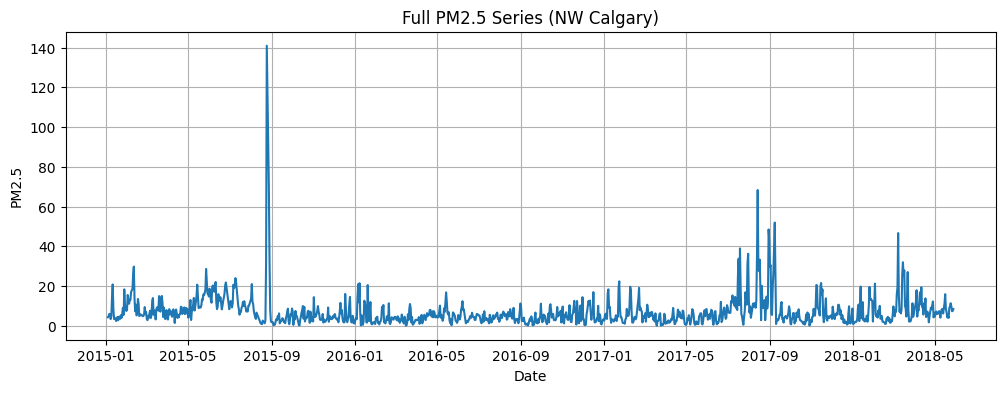

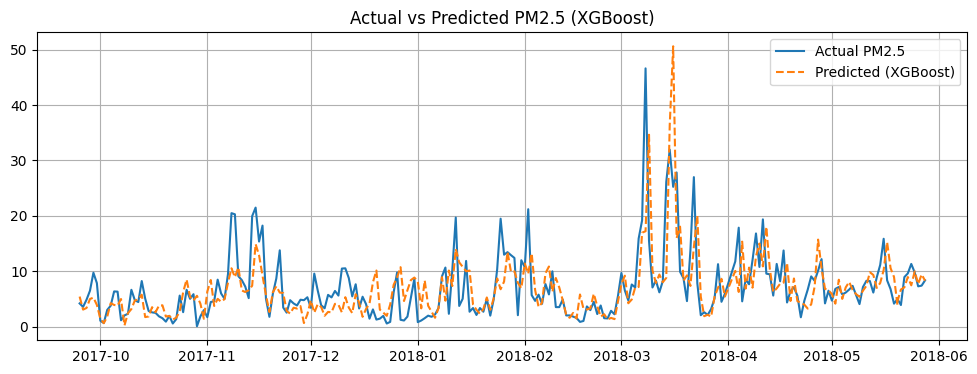

In [ ]:
#Plot of the full PM2.5 Time Series
plt.figure(figsize=(12,4))
plt.plot(df["date"], df["PM2.5"])
plt.title("Full PM2.5 Series (NW Calgary)")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.grid(True)
plt.show()


#Plot of the Actual versus Predicted AQI Values
plt.figure(figsize=(12,4))
plt.plot(df["date"].iloc[split_xgb:], y_test.values, label="Actual PM2.5")
plt.plot(df["date"].iloc[split_xgb:], xgb_preds, "--", label="Predicted (XGBoost)")
plt.legend()
plt.title("Actual vs Predicted PM2.5 (XGBoost)")
plt.grid(True)
plt.show()


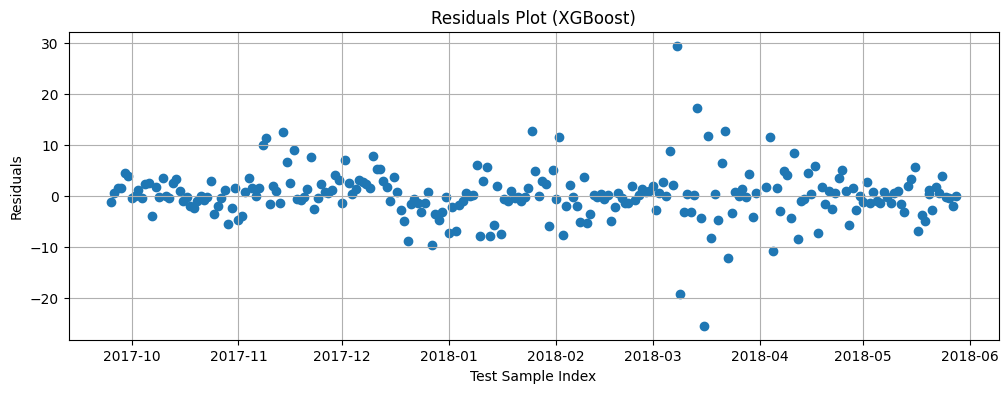

In [ ]:
#residuals = actual - predicted
residuals_xgb = y_test - xgb_preds

plt.figure(figsize=(12,4))
plt.scatter(df["date"].iloc[split_xgb:], residuals_xgb)
plt.xlabel("Test Sample Index")
plt.ylabel("Residuals")
plt.title("Residuals Plot (XGBoost)")
plt.grid(True)
plt.show()


**Feature Interpretation**

SHAP Feature and Importance Feature

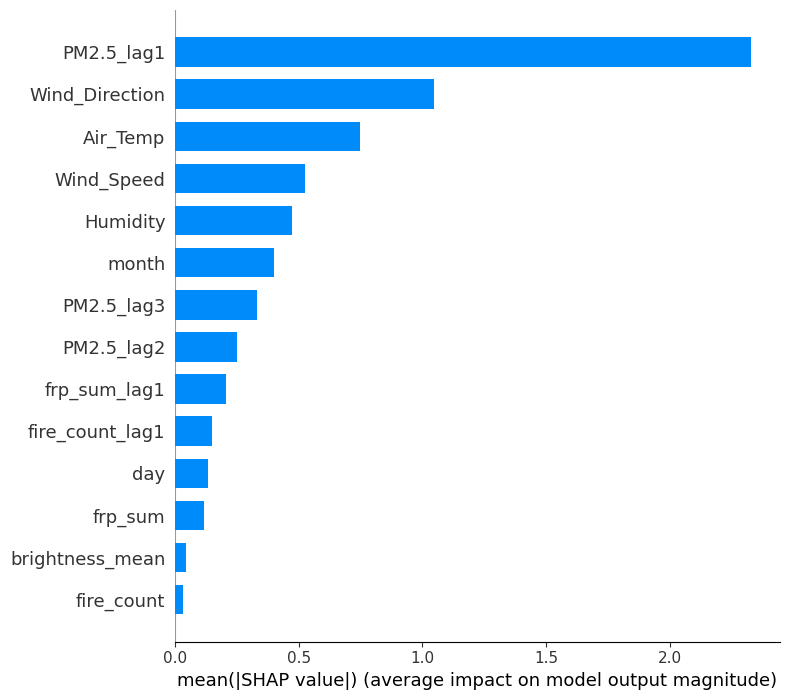

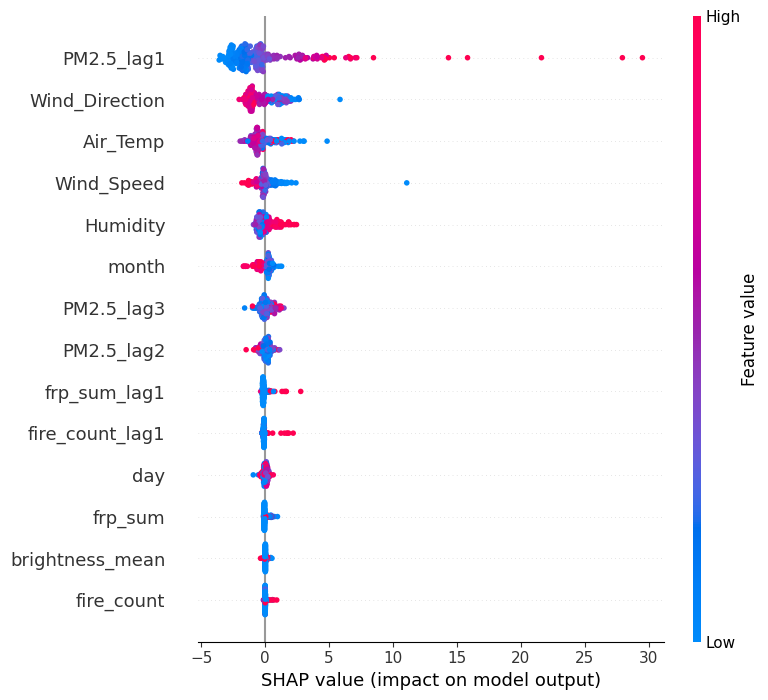

In [ ]:
import shap

#create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test)

#Summary plot (global feature importance)
shap.summary_plot(shap_values, x_test, plot_type="bar")

#direction of influence
shap.summary_plot(shap_values, x_test)


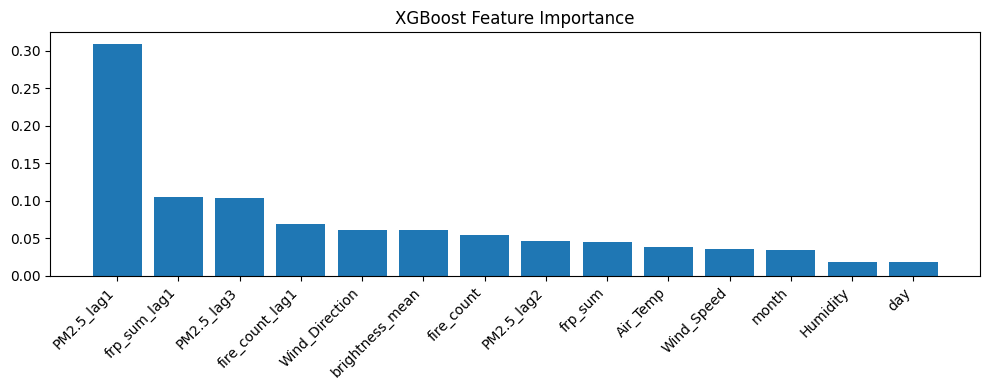

            feature  importance
7        PM2.5_lag1    0.308786
11     frp_sum_lag1    0.104904
9        PM2.5_lag3    0.103683
10  fire_count_lag1    0.068834
3    Wind_Direction    0.061472
6   brightness_mean    0.061076
4        fire_count    0.054873
8        PM2.5_lag2    0.046766
5           frp_sum    0.044469
0          Air_Temp    0.038968
2        Wind_Speed    0.035322
12            month    0.033767
1          Humidity    0.019002
13              day    0.018078


In [ ]:
importances = pd.DataFrame({
    "feature": x.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(importances["feature"], importances["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print(importances)

# **Predicting the PM2.5 Values using LSTM Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers, models
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#PM2.5 is used (as a univariate LSTM) because adding a multivariate
#inputs requires sequence aligned feature tensors

#Sorts by date
df_lstm = df.sort_values("date").reset_index(drop=True)
pm_series = df_lstm["PM2.5"].values.reshape(-1, 1)

#Scales the PM2.5 between 0 and 1
pm_scaler = MinMaxScaler(feature_range=(0, 1))
pm_scaled = pm_scaler.fit_transform(pm_series)

#Uses a fixed sliding window (14 days)
window_size = 14

def create_sequences(data, window):
  x_seq, y_seq = [], []
  for i in range(len(data) - window):
      x_seq.append(data[i:i+window, 0])
      y_seq.append(data[i+window, 0])
  return np.array(x_seq), np.array(y_seq)

x_seq, y_seq = create_sequences(pm_scaled, window_size)

#Reshapes the LSTM:(samples, timesteps, features)
x_seq = x_seq.reshape((x_seq.shape[0], x_seq.shape[1], 1))

print("x_seq shape:", x_seq.shape)
print("y_seq shape:", y_seq.shape)

x_seq shape: (1207, 14, 1)
y_seq shape: (1207,)


In [ ]:
#Data splitting
#Divide the data into training, validation and testing sets
split_lstm = int(len(x_seq) * 0.8)

#Testing set is used to evaluate the final models performance on unseen data
#Training set is used to train the model
#The data is split chronologically to maintain temporal integrity
x_train_seq, x_test_seq = x_seq[:split_lstm], x_seq[split_lstm:]
y_train_seq, y_test_seq = y_seq[:split_lstm], y_seq[split_lstm:]

print("Train sequences:", x_train_seq.shape[0])
print("Test sequences:", x_test_seq.shape[0])

Train sequences: 965
Test sequences: 242


In [ ]:
#To prevent overfitting of the model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
#Training the model
tf.keras.backend.clear_session()

#LSTM Architecture
model_lstm = Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(window_size, 1)),
    layers.Dropout(0.2),
    layers.LSTM(128),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_lstm.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
)

history = model_lstm.fit(
    x_train_seq, y_train_seq,
    validation_data=(x_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0032 - val_loss: 0.0015
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0013 - val

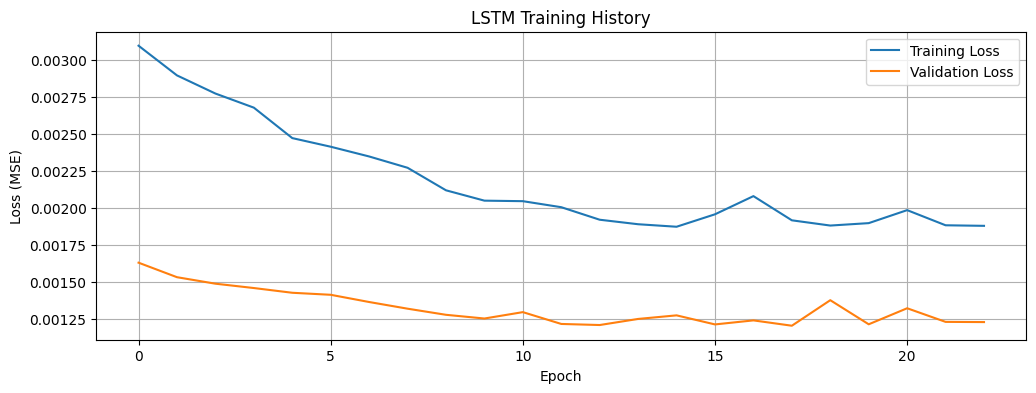

In [ ]:
#Plot of the training and validation loss/training history
#allows us to monitor the performance during training
plt.figure(figsize=(12,4))
plt.plot(history.history["loss"], label="Training Loss") #training loss
plt.plot(history.history["val_loss"], label="Validation Loss") #validation loss
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("LSTM Training History")
plt.grid(True)
plt.show()


In [51]:
#Predict scaled values
y_pred_seq = model_lstm.predict(x_test_seq)

#Inverse scale to real PM2.5 units
y_test_inv = pm_scaler.inverse_transform(y_test_seq.reshape(-1, 1))
y_pred_inv = pm_scaler.inverse_transform(y_pred_seq)

rmse_lstm = np.sqrt(mean_absolute_error(y_test_inv, y_pred_inv))

#Quantify the acuracy and reliability of the predictions
print("LSTM MAE:", mean_absolute_error(y_test_inv, y_pred_inv))
print("LSTM R² :", r2_score(y_test_inv, y_pred_inv))
print("LSTM RMSE:", rmse_lstm)

model_lstm.save("lstm_model.keras")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
LSTM MAE: 3.303151073501524
LSTM R² : 0.33313900840466915
LSTM RMSE: 1.8174573099529805


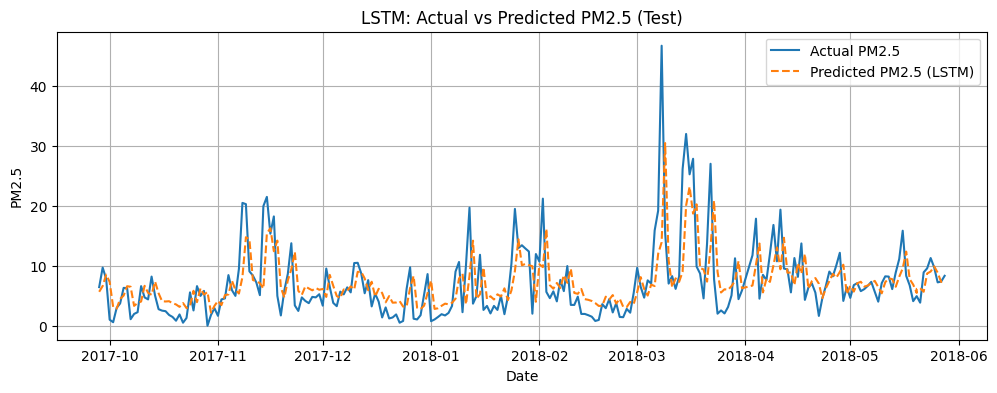

In [ ]:
#Plot of actual versus predicted PM2.5 values using LSTM
test_dates = df_lstm["date"].iloc[-len(y_test_inv):]

plt.figure(figsize=(12,4))
plt.plot(test_dates, y_test_inv, label="Actual PM2.5")
plt.plot(test_dates, y_pred_inv, "--", label="Predicted PM2.5 (LSTM)")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("LSTM: Actual vs Predicted PM2.5 (Test)")
plt.legend()
plt.grid(True)
plt.show()

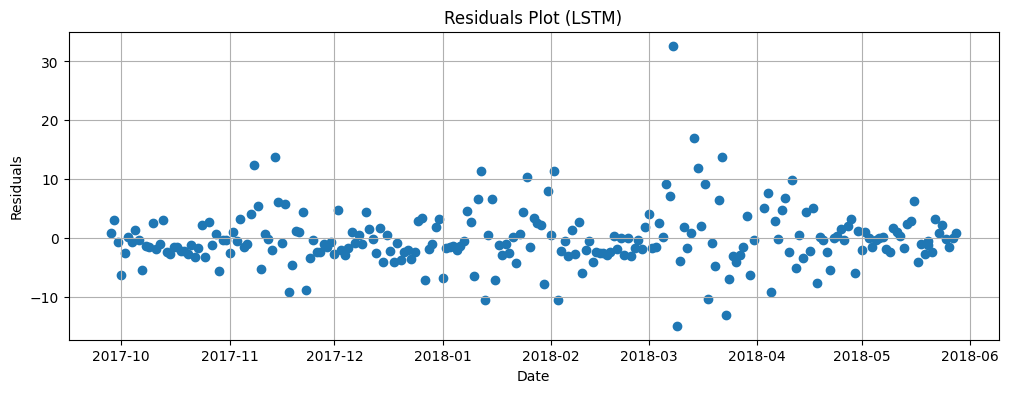

In [ ]:
residuals_lstm = y_test_inv - y_pred_inv

plt.figure(figsize=(12,4))
plt.scatter(test_dates, residuals_lstm)
plt.title("Residuals Plot (LSTM)")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

In [ ]:
print("Using XGBoost Modelling")
print("MAE:", mean_absolute_error(y_test, xgb_preds),"ug/m3")
print("R²:", r2_score(y_test, xgb_preds), "\n")

print("Using LSTM Modelling")
print("MAE:", mean_absolute_error(y_test_inv, y_pred_inv),"ug/m3")
print("R² :", r2_score(y_test_inv, y_pred_inv))

Using XGBoost Modelling
MAE: 3.1941682896165458 ug/m3
R²: 0.29524130672452753 

Using LSTM Modelling
MAE: 3.303151073501524 ug/m3
R² : 0.33313900840466915


# **Future AQI Prediction/Forecasting**

**A. Using XGBoost model**

Forecasts the future PM2.5 by recursively feeding predictions back into the lagged variables

In [ ]:
n_future = 7 #7day forecast

#Start from the last known row
last_row = df.iloc[-1].copy()

future_dates = []
future_pm25 = []

#Get the feature columns used for training the XGBoost model
feature_columns = x.columns.tolist()

for i in range(n_future):
    features_series = last_row.drop(labels=["date", "PM2.5"])
    x_future_row = pd.DataFrame([features_series.values], columns=feature_columns).astype(float)

    next_pm25 = xgb_model.predict(x_future_row)[0]

#Calculate the next date
    next_date = last_row["date"] + timedelta(days=1)

    future_dates.append(next_date)
    future_pm25.append(next_pm25)

#Updated lag features for the next PM2.5 iteration
    last_row["PM2.5_lag3"] = last_row["PM2.5_lag2"]
    last_row["PM2.5_lag2"] = last_row["PM2.5_lag1"]
    last_row["PM2.5_lag1"] = next_pm25

#Update wildfire lag features
    if "fire_count_lag1" in last_row.index:
        last_row["fire_count_lag1"] = last_row["fire_count"]
    if "frp_sum_lag1" in last_row.index:
        last_row["frp_sum_lag1"] = last_row["frp_sum"]

#Wildfire values are set to zero since future fire activity cannot be observed or predicted
    if "fire_count" in last_row.index:
        last_row["fire_count"] = 0.0
    if "frp_sum" in last_row.index:
        last_row["frp_sum"] = 0.0
    if "brightness_mean" in last_row.index:
        last_row["brightness_mean"] = 0.0

  #Update date for the next iteration
    last_row["date"] = next_date
    last_row["month"] = next_date.month
    last_row["day"] = next_date.day


xgb_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "PM2.5_forecast": future_pm25
})

print ("AQI values for a 7 day forecast are:", "\n", xgb_forecast_df)
display(xgb_forecast_df)

AQI values for a 7 day forecast are: 
         Date  PM2.5_forecast
0 2018-05-29        8.310487
1 2018-05-30        7.418485
2 2018-05-31        8.190825
3 2018-06-01        8.094530
4 2018-06-02        7.924498
5 2018-06-03        7.238783
6 2018-06-04        6.676716


,Date,PM2.5_forecast
0,2018-05-29,8.310487
1,2018-05-30,7.418485
2,2018-05-31,8.190825
3,2018-06-01,8.094530
4,2018-06-02,7.924498
5,2018-06-03,7.238783
6,2018-06-04,6.676716


**B. Using LSTM Model**

Predicts the next value by shifting the rolling window forward

In [ ]:
n_future_1 = 7

last_window1 = pm_scaled[-window_size:].flatten()
future_scaled1 = []

current_window1 = last_window1.copy()

for i in range(n_future_1):
    inp = current_window1.reshape(1, window_size, 1)
    next_scaled1 = model_lstm.predict(inp)[0, 0]
    future_scaled1.append(next_scaled1)

    current_window1 = np.append(current_window1[1:], next_scaled1)


future_pm25_lstm = pm_scaler.inverse_transform(
    np.array(future_scaled1).reshape(-1, 1)
).flatten()


last_date1 = df_lstm["date"].iloc[-1]
future_dates_lstm = [last_date1 + timedelta(days=i+1) for i in range(n_future_1)]

lstm_forecast_df = pd.DataFrame({
    "Date": future_dates_lstm,
    "PM2.5_forecast_LSTM": future_pm25_lstm
})

print("\n7 day Forecast using LSTM is:")
display(lstm_forecast_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

7 day Forecast using LSTM is:


,Date,PM2.5_forecast_LSTM
0,2018-05-29,8.078813
1,2018-05-30,7.868974
2,2018-05-31,7.771667
3,2018-06-01,7.756210
4,2018-06-02,7.809453
5,2018-06-03,7.882287
6,2018-06-04,7.954632


**AQHI Risk Mapping**

Allows User to Input AQI Value and Determine the Level of Risk for Predicted AQI





In [ ]:
def aqhi_risk_alert(pm):
    if pm <= 10:
        return {
            "level": "Low",
            "message": "Air quality is good.",
            "risk": "No action required."
        }
    elif pm <= 20:
        return {
            "level": "Moderate",
            "message": "Air quality is moderate.",
            "risk": "Children, seniors, and persons with respiratory issues should limit outdoor activity."
        }
    elif pm <= 30:
        return {
            "level": "High",
            "message": "Health risk is high.",
            "risk": "Limited outdoor activities. Stay indoors if you have lung or heart conditions."
        }
    else:
        return {
            "level": "Very High",
            "message": "Health risk is dangerous.",
            "risk": "Avoid outdoor activity entirely."
        }



Using the trained model (merged average) to predict future PM2.5 concentrations

In [ ]:
#Merges data to ensure correct alignment
merged_df=pd.merge(xgb_forecast_df, lstm_forecast_df, on="Date", how="inner")
merged_df["PM2.5_Forecast_merged"]=(merged_df["PM2.5_forecast"]+merged_df["PM2.5_forecast_LSTM"])/2


notifications = []

for i in range(len(merged_df)):
  pm_value = merged_df["PM2.5_Forecast_merged"].iloc[i]
  msg = aqhi_risk_alert(pm_value)

  notifications.append({
      "Date": merged_df["Date"].iloc[i],
      "PM2.5": round(pm_value,3),
      "Level of Risk": msg["level"],
      "Risk": msg["risk"],
      "Message": msg["message"]

  })
notifications_df = pd.DataFrame(notifications)
print("\n AQI style notifications for 7-day forecast:")
display(notifications_df)





 AQI style notifications for 7-day forecast:


,Date,PM2.5,Level of Risk,Risk,Message
0,2018-05-29,8.195,Low,No action required.,Air quality is good.
1,2018-05-30,7.644,Low,No action required.,Air quality is good.
2,2018-05-31,7.981,Low,No action required.,Air quality is good.
3,2018-06-01,7.925,Low,No action required.,Air quality is good.
4,2018-06-02,7.867,Low,No action required.,Air quality is good.
5,2018-06-03,7.561,Low,No action required.,Air quality is good.
6,2018-06-04,7.316,Low,No action required.,Air quality is good.


In [ ]:
pm_value_str = input("Enter the PM2.5 value: ")

try:
  pm_value = float(pm_value_str)
except:
  print("Invalid input. Please enter a valid value.")
else:
  message = aqhi_risk_alert(pm_value)
  print(f"Level of Risk: {message['level']}")
  print(f"Message: {message['message']}")
  print(f"Risk: {message['risk']}")

Enter the PM2.5 value: 3
Level of Risk: Low
Message: Air quality is good.
Risk: No action required.


In [54]:
!pip install streamlit

import streamlit as st
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from tensorflow.keras.models import load_model

st.title("Calgary NW – PM2.5 Prediction App")

# Upload user file
uploaded = st.file_uploader("Upload AQI or Weather File (CSV)", type="csv")

if uploaded:
    df = pd.read_csv(uploaded)
    st.write("Preview:", df.head())

# Predict button
if st.button("Predict AQI"):
    pred = xgb_model.predict(df_features)
    st.metric("Predicted PM2.5", f"{pred[0]:.2f} µg/m³")
    st.write(aqhi_risk_alert(pred[0]))



2025-12-01 07:11:35.821 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.822 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.823 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.825 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.827 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.830 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-01 07:11:35.832 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar